# Runtime analysis based on number of turbines

Run through 10 simulations where the farm layouts are randomly generated clusters with a mean turbine interspacing of 3.5D where D is the diameter of the turbine. Default turbine in use can be found in vestas_v802MW.yaml.

N_turbines = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

## Serial-Refine runtime

In [33]:
b = np.load(f"./data/horn/benchmark.npz")
b['wind_direction'], b['wind_speed'], b['weight']


(array([270.]), array([9.6]), array([1.]))

In [1]:
import numpy as np
wss = np.linspace(8, 15, 100)
wd = 270.0
weight = 1.0

for i in range(len(wss)):
    np.savez(f"./data/horn/yaw_variation_windspeed/yaw_var_{i}_.npz",
             wind_speed=[wss[i]],
             wind_direction=np.array([wd]),
             weight=[weight])

In [35]:
a = np.load(f"./data/horn/yaw_variation_windspeed/yaw_var_0.npz")
a['wind_direction'], a['wind_speed'], a['weight']

(array([270.]), array([8.]), array([1.]))

In [1]:
%load_ext autoreload
%autoreload 2
N_turbines = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

In [5]:
# N_turbines = [20, 30, 40]
N_turbines = [i for i in range(0, 100)]
for n in N_turbines:
    %run yaw_opt_sr.py --data-dir data/horn --farm-yaml gch.yaml --float64 --Nyaw 5 --Nyaw-refine 4 --gamma-max 25.0 --gamma-min 0.0 --out-dir results/yaw_discussion --weather-npz yaw_variation_windspeed/yaw_var_{n}.npz


Baseline mean power (MW): 36.049897
Running Serial-Refine (Nyaw=5, Nrefine=4)...
Execution took 5.020s
Optimised mean power (MW): 40.392608
Power Uplift: 12.046%

Optimal yaw angles (degrees):
[[25.     25.     25.     25.     25.     25.     25.     25.     20.3125
  20.3125 20.3125 20.3125 20.3125 20.3125 20.3125 20.3125 20.3125 20.3125
  20.3125 20.3125 20.3125 20.3125 20.3125 20.3125 17.1875 17.1875 17.1875
  17.1875 17.1875 17.1875 17.1875 17.1875 18.75   17.1875 17.1875 17.1875
  17.1875 17.1875 17.1875 17.1875 12.5    12.5    12.5    12.5    12.5
  12.5    12.5    12.5    10.9375  9.375  10.9375 10.9375 10.9375 10.9375
   9.375  10.9375  9.375   9.375   7.8125  7.8125  7.8125  7.8125  9.375
   9.375   4.6875  4.6875  4.6875  4.6875  4.6875  4.6875  4.6875  4.6875
   0.      0.      0.      0.      0.      0.      0.      0.    ]]
Baseline mean power (MW): 37.071061
Running Serial-Refine (Nyaw=5, Nrefine=4)...
Execution took 5.104s
Optimised mean power (MW): 41.532406
Power Uplif

In [2]:
N_turbines = list(range(110, 201, 10))
for n in N_turbines:
    %run yaw_opt_slsqp.py --data-dir data/clusters --farm-yaml gch{n}.yaml --float64 --max-iter 200 --patience 200 --lbfgs-memory 80 --restarts 3 --seed 0 --min-delta 1e-6 --gamma-max 25.0 --gamma-min 0.0


=== Restart 1/3 ===
SLSQP time (restart 0): 8.209s  iters=200 final_loss=-1.000000e+00
[restart 0] final mean power (MW): 10.531721

=== Restart 2/3 ===
SLSQP time (restart 1): 0.249s  iters=200 final_loss=-9.376346e-01
[restart 1] final mean power (MW): 9.874906

=== Restart 3/3 ===
SLSQP time (restart 2): 0.231s  iters=200 final_loss=-9.657906e-01
[restart 2] final mean power (MW): 10.171437

 === Finished 3 restarts in 8.746s ===
Best restart: 0, best mean power (MW): 10.531721
Best yaw angles (degrees): 
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

=== Restart 1/3 ===
SLSQP time (restart 0): 7.880s  iters=200 final_loss=-1.000000e+00
[restart 0] final mean power (MW): 21.425268

=== Restart 2/3 ===
SLSQP time (restart 1): 0.708s  iters=200 final_loss=-9.810142e-01
[restart 1] final mean power (MW): 21.018492

=== Restart 3/3 ===
SLSQP time (restart 2): 0.705s  iters=200 final_loss=-9.552349e-01
[restart 2] final mean power (MW): 20.466165

 === Finished 3 restarts in 9.318s ===
Best restart

In [ ]:
N_turbines = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
for n in N_turbines:
    %run yaw_opt_bayes.py --data-dir data/clusters --farm-yaml gch{n}.yaml --float64 --max-iter 200 --patience 200 --acq LCB --lcb-kappa 2.576 --seed 0 --min-delta 1e-6 --gamma-max 25.0 --gamma-min 0.0 --seed 0

Baseline loss: 1.0
Baseline power: 10.531721 MW
Iter 0001, loss=-9.980105e-01, best=-9.980105e-01 No improvement count = 0, time=1.810s
Iter 0002, loss=-9.788590e-01, best=-9.980105e-01 No improvement count = 1, time=1.582s
Iter 0003, loss=-9.481291e-01, best=-9.980105e-01 No improvement count = 2, time=0.084s
Iter 0004, loss=-9.902821e-01, best=-9.980105e-01 No improvement count = 3, time=0.091s
Iter 0005, loss=-9.914909e-01, best=-9.980105e-01 No improvement count = 4, time=0.050s
Iter 0006, loss=-9.784567e-01, best=-9.980105e-01 No improvement count = 5, time=0.046s
Iter 0007, loss=-9.687656e-01, best=-9.980105e-01 No improvement count = 6, time=0.050s
Iter 0008, loss=-9.920374e-01, best=-9.980105e-01 No improvement count = 7, time=0.046s
Iter 0009, loss=-9.869304e-01, best=-9.980105e-01 No improvement count = 8, time=0.061s
Iter 0010, loss=-9.742427e-01, best=-9.980105e-01 No improvement count = 9, time=0.050s
Iter 0011, loss=-9.745767e-01, best=-9.980105e-01 No improvement count =

In [4]:
## Horns Rev 1
%run yaw_opt_sr.py --data-dir data/horn --farm-yaml gch.yaml --float64 --weather-npz benchmark.npz --Nyaw 5 --Nyaw-refine 4 --gamma-max 25.0 --gamma-min 0.0 --out-dir results/yaw_serial_hr1

Baseline mean power (MW): 63.492160
Running Serial-Refine (Nyaw=5, Nrefine=4)...
Execution took 5.566s
Optimised mean power (MW): 75.777309
Power Uplift: 19.349%


In [14]:
y0s = [12.5]
for i in y0s:
    %run yaw_opt_slsqp.py --data-dir data/horn --farm-yaml gch.yaml --float64 --max-iter 130 --patience 130 --lbfgs-memory 20 --restarts 1 --seed 0 --min-delta 1e-6 --gamma-max 25.0 --gamma-min 0.0 --out-dir results/yaw_slsqp_hr1 --weather-npz benchmark.npz --out-dir results/yaw_slsqp_hr1 --y0 {i}


=== Restart 1/1 ===
SLSQP time (restart 0): 82.608s  iters=130 final_loss=-1.178306e+00
[restart 0] final mean power (MW): 74.813175

 === Finished 1 restarts in 82.608s ===
Best restart: 0, best mean power (MW): 74.813175
Best yaw angles (degrees): 
[[13.23993907 12.49684424 12.49684424 12.49684424 12.49684424 25.0000016
  25.00000152 25.00000144 22.22740423 20.97098682 22.09032491 21.30811949
  21.06210893 19.06083198 18.53083537 18.67752824 17.7583944  18.51204353
  18.61095625 17.62584475 18.45259778 18.36053667 17.59836311 17.55951739
  16.12803858 16.56002249 17.58546531 16.49326589 16.53903362 16.0134399
  16.40749458 16.44549765 15.8056957  15.51868025 15.37010249 15.46562439
  15.48336499 14.82742268 15.31792488 15.37270202 14.74448544 14.30879785
  15.46714521 14.45625295 14.51331358 14.26194518 13.8789238  14.01493676
  13.9448558  13.32873255 13.43142966 13.29209189 13.61570687 13.05779352
  12.90931203 13.14202514 13.18172865 11.06134303 11.97331027 11.90078378
  11.63465

In [6]:
%run yaw_opt_bayes.py --data-dir data/horn --farm-yaml gch.yaml --float64 --max-iter 200 --patience 200 --acq LCB --lcb-kappa 2.576 --seed 0 --min-delta 1e-6 --gamma-max 25.0 --gamma-min 0.0 --out-dir results/yaw_bayes_hr1

Baseline loss: -1.0
Baseline power: 63.492160 MW
Iter 0001, loss=-1.132070e+00, best=-1.132070e+00 No improvement count = 0, time=3.624s
Iter 0002, loss=-1.127132e+00, best=-1.132070e+00 No improvement count = 1, time=6.488s
Iter 0003, loss=-1.130408e+00, best=-1.132070e+00 No improvement count = 2, time=6.361s
Iter 0004, loss=-1.127597e+00, best=-1.132070e+00 No improvement count = 3, time=7.538s
Iter 0005, loss=-1.138308e+00, best=-1.138308e+00 No improvement count = 0, time=7.326s
Iter 0006, loss=-1.122990e+00, best=-1.138308e+00 No improvement count = 1, time=7.314s
Iter 0007, loss=-1.120023e+00, best=-1.138308e+00 No improvement count = 2, time=6.553s
Iter 0008, loss=-1.115052e+00, best=-1.138308e+00 No improvement count = 3, time=6.584s
Iter 0009, loss=-1.125674e+00, best=-1.138308e+00 No improvement count = 4, time=6.580s
Iter 0010, loss=-1.143869e+00, best=-1.143869e+00 No improvement count = 0, time=6.730s
Iter 0011, loss=-1.129093e+00, best=-1.143869e+00 No improvement count 

In [ ]:
# NEW CELL

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys
import os

# Ensure the DiffWake directory is in the path so we can import from it
sys.path.append(os.path.abspath("."))
from yaw_opt_sr import run_optimization, parse_args

def run_simulation_direct(precision):
    # Prepare arguments. Passing [] to parse_args to ignore sys.argv (which contains Jupyter flags)
    args = parse_args()
    args.data_dir = Path("data/horn")
    args.farm_yaml = "gch.yaml"
    args.Nyaw = 5
    args.Nyaw_refine = 4
    args.gamma_max = 25.0
    args.gamma_min = 0.0
    args.weather_npz = "benchmark.npz"
    args.out_dir = Path("results/yaw_opt_fp")
    args.precision = precision
    args.float64 = (precision == "float64")
    
    # We call run_optimization directly. 
    # Note: Switching precision (especially enabling/disabling float64) 
    # within the same process might have limitations in JAX if not handled carefully,
    # but run_optimization calls setup_dtype which updates jax.config.
    res = run_optimization(args)
    return res.get("total_elapsed_time", 0.0)

runtimes_fp64 = []
runtimes_fp32 = []
runtimes_fp16 = []
runtimes_bf16 = []

N_BENCH = 50

# Note: We run FP64 last if we suspect jax_enable_x64(True) cannot be undone easily in some versions,
# but here we follow the requested order and rely on setup_dtype.

print(f"Running {N_BENCH} simulations with --precision float64...")
for i in range(N_BENCH):
    t = run_simulation_direct("float64")
    runtimes_fp64.append(t)
    if (i + 1) % 10 == 0:
        print(f"Completed {i+1}/{N_BENCH} FP64")

print(f"\nRunning {N_BENCH} simulations with --precision float32...")
for i in range(N_BENCH):
    t = run_simulation_direct("float32")
    runtimes_fp32.append(t)
    if (i + 1) % 10 == 0:
        print(f"Completed {i+1}/{N_BENCH} FP32")

print(f"\nRunning {N_BENCH} simulations with --precision float16...")
for i in range(N_BENCH):
    t = run_simulation_direct("float16")
    runtimes_fp16.append(t)
    if (i + 1) % 10 == 0:
        print(f"Completed {i+1}/{N_BENCH} FP16")

print(f"\nRunning {N_BENCH} simulations with --precision bfloat16...")
for i in range(N_BENCH):
    t = run_simulation_direct("bfloat16")
    runtimes_bf16.append(t)
    if (i + 1) % 10 == 0:
        print(f"Completed {i+1}/{N_BENCH} BF16")

# Save results to avoid losing them
np.savez("results/runtime_comparison.npz", 
         fp64=runtimes_fp64, fp32=runtimes_fp32, 
         fp16=runtimes_fp16, bf16=runtimes_bf16)


Running 50 simulations with --precision float64...
Exporting HLO graph to results\yaw_opt_fp\20260531_212049\hlo_graph.txt...
Baseline mean power (MW): 63.505928
Running Serial-Refine (Nyaw=5, Nrefine=4)...
Execution took 4.645s
Total time (inc. JIT): 5.491s
Optimised mean power (MW): 70.485468
Power Uplift: 10.990%

Optimal yaw angles (degrees):
[[25.     25.     25.     25.     25.     25.     25.     25.     17.1875
  17.1875 17.1875 17.1875 17.1875 17.1875 17.1875 17.1875 17.1875 17.1875
  17.1875 17.1875 17.1875 17.1875 17.1875 17.1875 17.1875 17.1875 17.1875
  17.1875 17.1875 17.1875 17.1875 17.1875 15.625  17.1875 17.1875 17.1875
  17.1875 17.1875 17.1875 15.625  15.625  14.0625 14.0625 14.0625 14.0625
  14.0625 14.0625 15.625  10.9375 10.9375 10.9375  9.375   9.375  10.9375
  10.9375 10.9375 10.9375  9.375   9.375   9.375   9.375   9.375   9.375
   9.375   4.6875  4.6875  4.6875  4.6875  4.6875  4.6875  4.6875  4.6875
   0.      0.      0.      0.      0.      0.      0.      0

In [7]:
import matplot2tikz

C:\Users\johnn\AppData\Local\Temp\ipykernel_100304\2315449494.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=annotated_labels, orientation='horizontal')


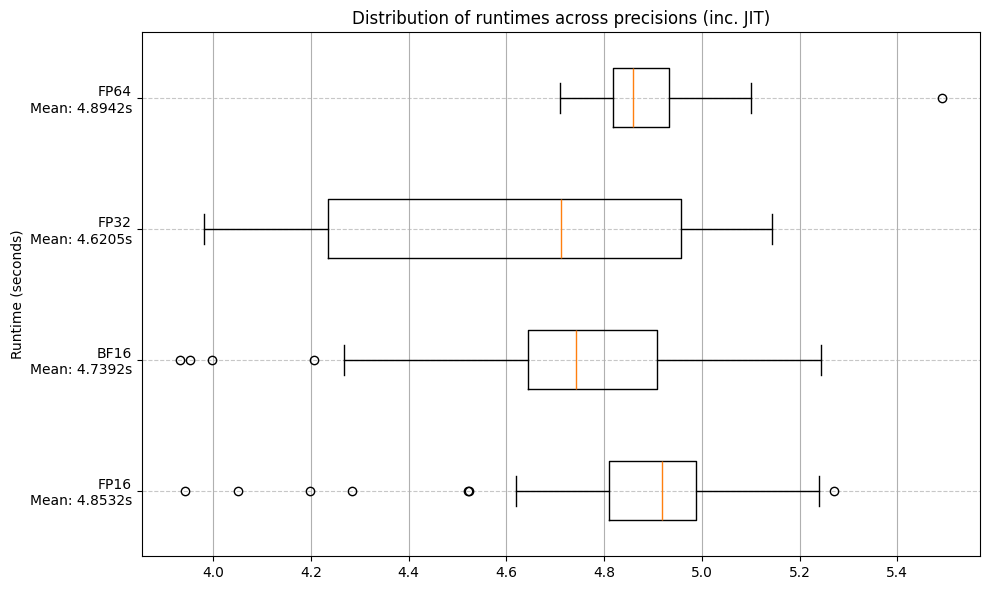

In [8]:


# Data lists (assuming these exist in your environment)
data = [runtimes_fp16, runtimes_bf16, runtimes_fp32, runtimes_fp64]
base_labels = ['FP16', 'BF16', 'FP32', 'FP64']

# Calculate means
means = [np.mean(d) for d in data]

# Create annotated labels
annotated_labels = [f'{label}\nMean: {mean:.4f}s' for label, mean in zip(base_labels, means)]

plt.style.use('default')
plt.figure(figsize=(10, 6))

# Use the annotated labels
plt.boxplot(data, labels=annotated_labels, orientation='horizontal')

plt.ylabel('Runtime (seconds)')
plt.title('Distribution of runtimes across precisions (inc. JIT)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x')
# Save the figure as requested
plt.tight_layout()
matplot2tikz.save("../plotting/latex/fp_performance_2.tex")

In [5]:
print(f"FP16: {np.mean(runtimes_fp16):.4f}s")
print(f"BF16: {np.mean(runtimes_bf16):.4f}s")
print(f"FP32: {np.mean(runtimes_fp32):.4f}s")
print(f"FP64: {np.mean(runtimes_fp64):.4f}s")

FP16: 4.8532s
BF16: 4.7392s
FP32: 4.6205s
FP64: 4.8942s
